# Pywr Thames Sensitivitiy Analysis workflow
This notebook uses the outputs from the Pywr Thames Sensitivity Analysis workflow to carry out a global sensitivity analysis. The model source code can be found here: https://github.com/SAFEtoolbox/SAFE-on-DAFNI. The purpose of this excersise is to quantify the output uncertainty and sensitivity by investigating the propgration of uncertainties and analysising the input-output dataset. 

The first stage of the sensitivity analysis (where we propograte the input uncertainties through the model) has been conducted using the parameter sweep. The model input parameters have been sampled 200 times between realistic bounds. Note that the input bounds and number of model runs can be edited to suit the users needs by manipulating the parameter sets within the workflow. 

The inputs that we have sampled are: 
1. The cost parameters representing (1) the minimum flow requirement (mfr), (2) the reservoir and (3) the demand. 
2. The value for the mfr
3. The baseline demand value
4. The restriction scenario (we sample this dicretely from 3 choices representing the default restrictions, a set of optimistic restrictions and a set of conservative restrictions, for more information please see the source code)
5. The time period across which the model is run (we sample this dicretely from 3 choices representing 2100-2133, 2133 - 2166 and 2166- 2199)

The outputs which the model produces represent: 
1. The mean summer reservoir storage (in months June, July and August) 
2. The mean winter reservoir storage (in months December, January and February) 
3. The number of days where the mfr is not met. 
4. The number of days where there are level 2 restrictions implemented. 
5. The number of days where the demand is not met. 

The second stage of the sensitivity analysis is carried out in this notebook. The following code will take you through the process of quantifying the uncertainty and sensitivity in the model outputs listed above. 

In [1]:
# Import libraries needed for analysis
import os 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import glob

In this example we use the SAFE toolbox to carry out the sensitivity analysis, we use the PAWN method. For more information see: https://safetoolbox.github.io/

In [2]:
# Install the SAFE Toolbox 
!pip install safepython
import safepython

In [3]:
# Check working directory 
os.getcwd()

'/home/jovyan/data/4a4599fe-7aa8-40d5-9302-4579b8462840'

In [4]:
# Import necessary libraraies from the SAFE Toolbox 
from __future__ import division, absolute_import, print_function

import sys
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatRangeSlider, IntRangeSlider
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore') # to hide warning messages
# Module to perform PAWN:
import safepython.PAWN as PAWN
# Module to visualize the results:
import safepython.plot_functions as pf
# Module to execute the model
from safepython.model_execution import model_execution
# Functions to perform the input sampling
from safepython.sampling import AAT_sampling, AAT_sampling_extend
from safepython.util import below, aggregate_boot

We first need to read in the output files from the parameter sweep. For this model we have 2 types of file, the first begins with 'params_' and contains the parameter values used for that unique simulation. The second begins with 'outputs_' and contains the outputs specified by the model code.

In [6]:
directory = "./"
file_paths_params = glob.glob(os.path.join(directory, "params*"))
file_paths_outputs = glob.glob(os.path.join(directory, "output*"))

Since the parameter sweep outputs individual fiels for each model simulation we now want to combine them into input and output datasets. 

In [9]:
# Load parameter sets into a NumPy array
params_list = [np.loadtxt(file, delimiter=',') for file in file_paths_params]
params_output = np.column_stack(params_list)  # Stack columns

# Define the column order
columns = ['mfr_cost', 'res_cost', 'demand_cost', 'mfr', 'demand_baseline', 'restriction_scenario', 'time_period', 'ID']

# Calculate 'mfr_cost'
params_output[0, :] = 1 - (params_output[1, :] + params_output[2, :])

print(params_output[:,0])  

# Load model outputs into a NumPy array
outputs_list = [np.loadtxt(file, delimiter=',') for file in file_paths_outputs]
output_output = np.column_stack(outputs_list)  # Stack columns

# Define the column order for outputs
output_columns = ['summer_res', 'winter_res', 'days_below_mrf', 'level2_res', 'below_dem_thresh']

#print(output_output)  

[1.68681556e-01 6.29410641e-01 2.01907802e-01 8.46460382e-01
 1.12621954e+00 1.00000000e+00 0.00000000e+00 1.03070000e+04]


We refer to the input dataset as X and the output dataset as Y. 

In [16]:
X = params_output[:7,:] # note that we don't need to include the ID in the input dataset, this is purely an identifier and does not influence the model output 
Y_full = output_output
Y = Y_full[0,:]
print(X.shape) # we have 7 inputs and ran the model 200 times
print(Y_full.shape) # we have 5 outputs and ran the model 200 times

(7, 200)
(5, 200)


Initially, it is often useful to plot the input-output dataset to get a visual idea of the relationships between inputs and outputs. 

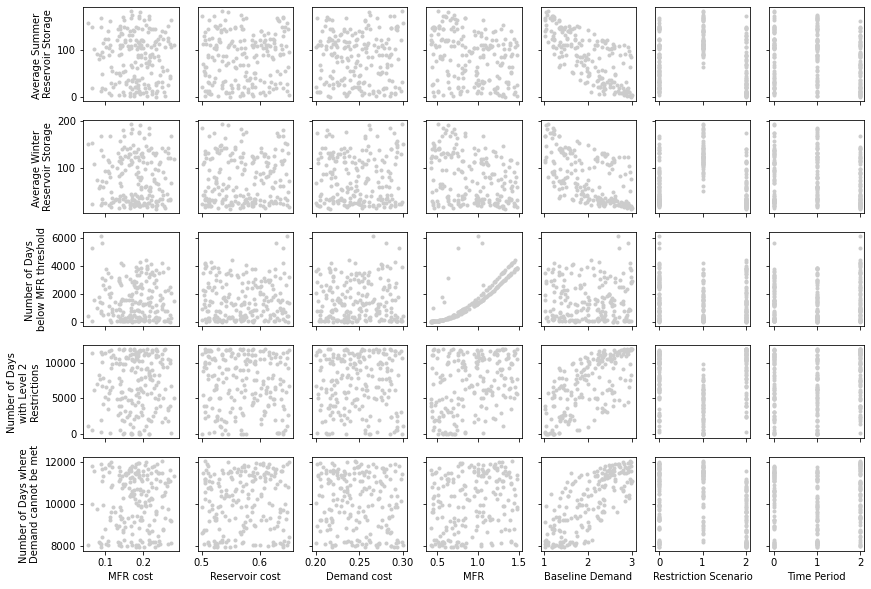

In [13]:
X_Labels =  ['MFR cost', 'Reservoir cost', 'Demand cost', 'MFR', 'Baseline Demand', 'Restriction Scenario', 'Time Period']
Y_Labels = ['Average Summer \nReservoir Storage','Average Winter \nReservoir Storage', 'Number of Days \nbelow MFR threshold', 'Number of Days \nwith Level 2 \nRestrictions', 'Number of Days where \nDemand cannot be met']
P=len(Y_Labels)
M=len(X_Labels)
plt.figure(figsize=[2*M,2*P])
# Scatter plots of Output 1 versus each input parameter
k = 0
for j in range(P):
    for i in range(M):
        plt.subplot(P,M,k+1)
        plt.plot(X[i, :], Y_full[j,:] , '.', markerfacecolor='0.8', markeredgecolor='0.8')
        plt.tick_params(axis='y',label1On=False)
        plt.tick_params(axis='x',label1On=False)
        if i==0:
            plt.ylabel(Y_Labels[j] ) 
            plt.tick_params(axis='y',label1On=True)
        if j==P-1:
            plt.xlabel(X_Labels[i] )
            plt.tick_params(axis='x',label1On=True)
        k=k+1
plt.show()

Visually, the inputs with the strongest output relationships appear to be baseline demand and restriction scenario. It is also very clear that the mfr has a strong relationship with the count_below_mfr output. 

We will now quantify these relationships by using the PAWN method to calculate sensitivity indicies. These metrics describe how much each input is contributing to the output uncertainty. The higher the metric, the more this input is having an influence on the output. Note that we have added an extra X variable called a dummy variable, the represents the threshold below which the output sensitivity is undetectable. 

<AxesSubplot:>

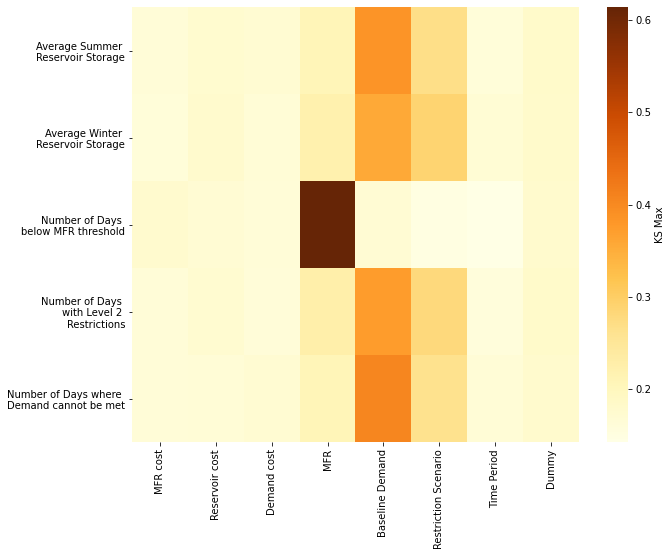

In [14]:
# Add the dummy variable to the X labels
X_Labels_dummy =  ['MFR cost', 'Reservoir cost', 'Demand cost', 'MFR', 'Baseline Demand', 'Restriction Scenario', 'Time Period', 'Dummy']

# To calculate the sensitivity indicies we must define the conditioning intervals for each input
n = [5, 5, 5, 5, 5, 3, 3] 

#Use bootstrapping to derive confidence bounds:
Nboot = 1000
# Compute sensitivity indices for Nboot bootstrap resamples across all outputs

KS_results = {}

# Loop through the labels and indices
for i, label in enumerate(Y_Labels):
    KS_median, KS_mean, KS_max, KS_dummy = PAWN.pawn_indices(X.T, Y_full[i, :], n, Nboot=Nboot, dummy=True) # KS_median and KS_mean and KS_max have shape (Nboot, M)
    KS_med = np.column_stack((KS_median, KS_dummy)) # Note that here we are using KS_median, but the same plot could be produced using KS_max or KS_mean 
    KS_med_m, KS_med_lb, KS_med_ub = aggregate_boot(KS_med)  # shape (M,)
    KS_results[label] = KS_med_m

# Combine results
KS_all = np.column_stack([KS_results[label] for label in Y_Labels])

# Produce heatmap of sensitivity indicies to compare across outputs 
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(
    KS_all.T, 
    cmap='YlOrBr', 
    xticklabels=X_Labels_dummy, 
    yticklabels=Y_Labels, 
    cbar_kws={'label': 'KS Max'}
)

So far we have considered all the outputs at the same time, but it is also possible to look in more detail at the relationship between a chosen output and the inputs. Below we will look in more detail at the relationship between the number of days with level 2 restrictions and the inputs. First we will visualise the CDF's for each of the conditioning intervals. 

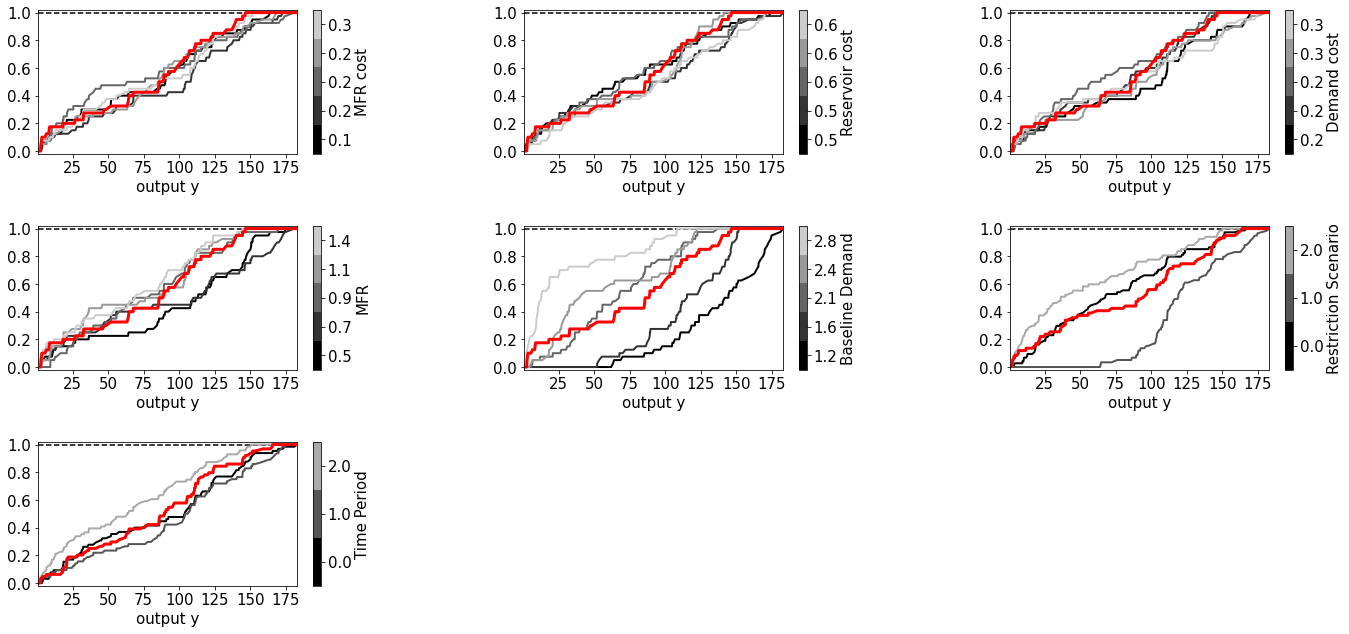

In [54]:
# Compute and plot conditional and unconditional CDFs:
YF, FU, FC, xc = PAWN.pawn_plot_cdf(X.T, Y, n, cbar=True, n_col=3, labelinput=X_Labels)

# Adjust layout 
plt.gcf().set_size_inches(20, 10)  # Set width to 20 inches, height to 6 inches
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, hspace=0.5, wspace=0.5)
plt.show()

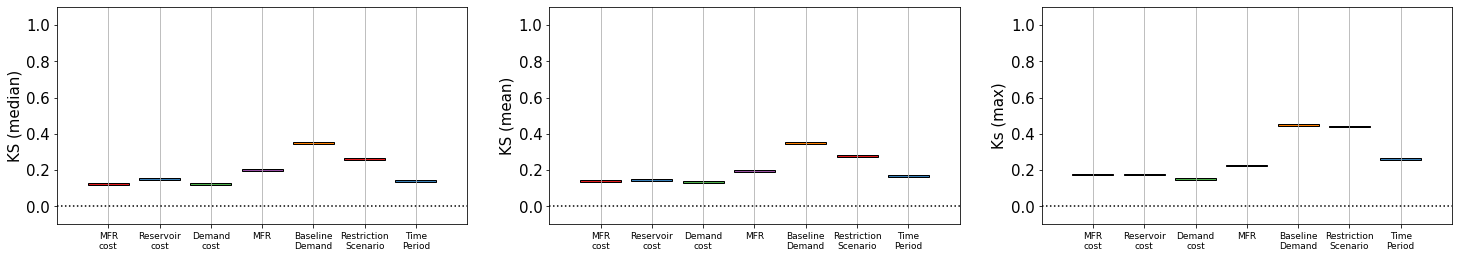

In [69]:
# Compute PAWN sensitivity indices:

X_Labels =  ['MFR\ncost', 'Reservoir\ncost', 'Demand\ncost', 'MFR', 'Baseline\nDemand', 'Restriction\nScenario', 'Time\nPeriod']
KS_median, KS_mean, KS_max = PAWN.pawn_indices(X, Y, n, output_condition=below, par=[150])
# Plot results:
plt.figure(figsize = (25,4))
plt.subplot(131)
pf.boxplot1(KS_median, X_Labels=X_Labels, Y_Label='KS (median)')
plt.xticks(fontsize=9) 
plt.subplot(132)
pf.boxplot1(KS_mean, X_Labels=X_Labels, Y_Label='KS (mean)')
plt.xticks(fontsize=9) 
plt.subplot(133)
pf.boxplot1(KS_max, X_Labels=X_Labels, Y_Label='Ks (max)')
plt.xticks(fontsize=9) 
plt.show()

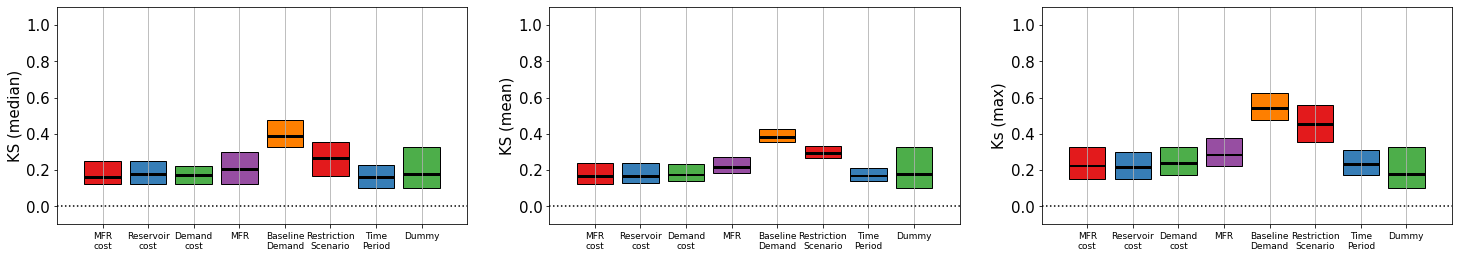

In [78]:
# Use bootstrapping to derive confidence bounds:
Nboot = 1000
# Compute sensitivity indices for Nboot bootstrap resamples
# (Warning: the following line may take some time to run, as the computation of
# CDFs is costly):
KS_median, KS_mean, KS_max, KS_dummy = PAWN.pawn_indices(X, Y, n, Nboot=Nboot, dummy = True)
# KS_median and KS_mean and KS_max have shape (Nboot, M)
# Compute mean and confidence intervals of the sensitivity indices across the
# bootstrap resamples:
KS_max = np.column_stack((KS_max, KS_dummy))
KS_median = np.column_stack((KS_median, KS_dummy))
KS_mean = np.column_stack((KS_mean, KS_dummy))


KS_median_m, KS_median_lb, KS_median_ub = aggregate_boot(KS_median) # shape (M,)
KS_mean_m, KS_mean_lb, KS_mean_ub = aggregate_boot(KS_mean) # shape (M,)
KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_max) # shape (M,)


X_Labels =  ['MFR\ncost', 'Reservoir\ncost', 'Demand\ncost', 'MFR', 'Baseline\nDemand', 'Restriction\nScenario', 'Time\nPeriod', 'Dummy']
# Plot bootstrapping results:
plt.figure(figsize = (25,4))
plt.subplot(131)
pf.boxplot1(KS_median_m, S_lb=KS_median_lb, S_ub=KS_median_ub,
             X_Labels=X_Labels, Y_Label='KS (median)')
plt.xticks(fontsize=9) 
plt.subplot(132)
pf.boxplot1(KS_mean_m, S_lb=KS_mean_lb, S_ub=KS_mean_ub,
            X_Labels=X_Labels, Y_Label='KS (mean)')
plt.xticks(fontsize=9) 
plt.subplot(133)
pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub,
            X_Labels=X_Labels, Y_Label='Ks (max)')
plt.xticks(fontsize=9) 
plt.show()


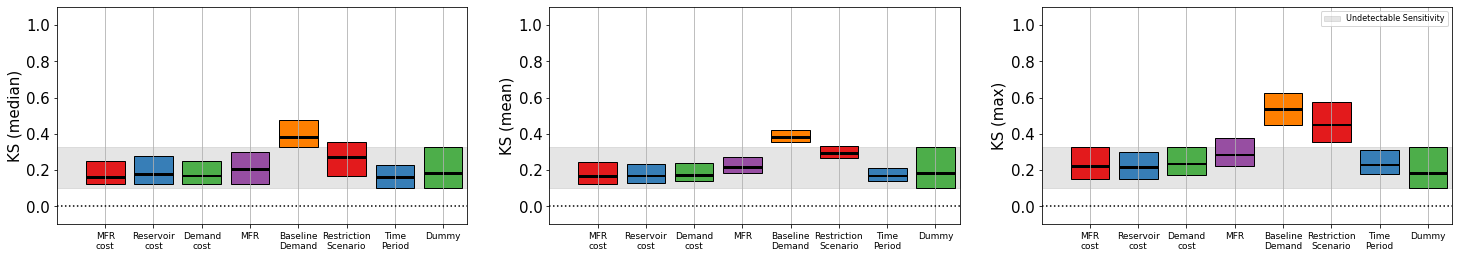

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# Compute bootstrapping confidence bounds
Nboot = 1000

# Compute sensitivity indices for Nboot bootstrap resamples
KS_median, KS_mean, KS_max, KS_dummy = PAWN.pawn_indices(X, Y, n, Nboot=Nboot, dummy=True)

# Append dummy variable results
KS_max = np.column_stack((KS_max, KS_dummy))
KS_median = np.column_stack((KS_median, KS_dummy))
KS_mean = np.column_stack((KS_mean, KS_dummy))

# Compute mean and confidence intervals
KS_median_m, KS_median_lb, KS_median_ub = aggregate_boot(KS_median)
KS_mean_m, KS_mean_lb, KS_mean_ub = aggregate_boot(KS_mean)
KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_max)

# Define X labels
X_Labels = ['MFR\ncost', 'Reservoir\ncost', 'Demand\ncost', 'MFR', 
            'Baseline\nDemand', 'Restriction\nScenario', 'Time\nPeriod', 'Dummy']

dummy_index = len(X_Labels) - 1  # Index of "Dummy" (last one)
x_min, x_max = 0, len(X_Labels) + 0.5  # Ensure full x-axis coverage

# Plot bootstrapping results
plt.figure(figsize=(25, 4))

plt.subplot(131)
pf.boxplot1(KS_median_m, S_lb=KS_median_lb, S_ub=KS_median_ub,
             X_Labels=X_Labels, Y_Label='KS (median)')
plt.xticks(fontsize=9)

# Add grey shading to visualise Dummy Y bounds 
plt.fill_between(
    x=[x_min, x_max], 
    y1=KS_median_lb[dummy_index], 
    y2=KS_median_ub[dummy_index], 
    color='grey', alpha=0.2, label='Undetectable Sensitivity'
)

plt.xlim(x_min, x_max)  # Ensure full x-axis is shown

plt.subplot(132)
pf.boxplot1(KS_mean_m, S_lb=KS_mean_lb, S_ub=KS_mean_ub,
            X_Labels=X_Labels, Y_Label='KS (mean)')
plt.xticks(fontsize=9)

# Add grey shading to visualise Dummy Y bounds 
plt.fill_between(
    x=[x_min, x_max], 
    y1=KS_mean_lb[dummy_index], 
    y2=KS_mean_ub[dummy_index], 
    color='grey', alpha=0.2, label='Undetectable Sensitivity'
)

plt.xlim(x_min, x_max)

plt.subplot(133)
pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub,
            X_Labels=X_Labels, Y_Label='KS (max)')
plt.xticks(fontsize=9)

# Add grey shading to visualise Dummy Y bounds 
plt.fill_between(
    x=[x_min, x_max], 
    y1=KS_max_lb[dummy_index], 
    y2=KS_max_ub[dummy_index], 
    color='grey', alpha=0.2, label='Undetectable Sensitivity'
)

plt.xlim(x_min, x_max)

# Add legend for the shading
plt.legend(loc='upper right')

plt.show()

